# Assignment 2

## Part 1: Data Visualization and Insight

In [76]:
#Importing the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [77]:
#Loading the dataset
df = pd.read_csv("Product Demand.csv")
#Preview of the dataset
df.head()

,Product_Code,Warehouse,Product_Category,Date,Order_Demand
0,Product_0965,St john's,Category_006,2014-01-08,2.0
1,Product_1724,St john's,Category_003,2014-05-31,108.0
2,Product_1521,Surrey,Category_019,2014-06-24,85000.0
3,Product_1521,Surrey,Category_019,2014-06-24,7000.0
4,Product_1507,Oshawa,Category_019,2014-09-02,1250.0


In [78]:
#Finding the Dataset Shape
print(df.shape)

#Checking the Data Types & Structure
print(df.info())

(1048575, 5)
<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 5 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Product_Code      1048575 non-null  str    
 1   Warehouse         1048575 non-null  str    
 2   Product_Category  1048575 non-null  str    
 3   Date              1037336 non-null  str    
 4   Order_Demand      1048575 non-null  float64
dtypes: float64(1), str(4)
memory usage: 81.9 MB
None


In [79]:
#Checking the Missing Values 
print(df.isnull().sum())

Product_Code            0
Warehouse               0
Product_Category        0
Date                11239
Order_Demand            0
dtype: int64


### Key Findings
- Dataset contains over **1 million records**.  
- Most variables are complete with **no missing values**.  
- The **Date column has 11,239 missing values** and is stored as a string.  
- Since the analysis depends on time-based grouping and forecasting, the Date field must be cleaned and converted before further analysis. 

## Cleaning Date and preparing the dataset

In [80]:
# Convert Date column into datetime format
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d', errors='coerce')

# Drop invalid dates
df = df.dropna(subset=['Date'])

# Sort by Date
df = df.sort_values(by='Date')

# Checking the dataset after conversion and cleaning
print(df.isnull().sum())
print(df.head())


Product_Code        0
Warehouse           0
Product_Category    0
Date                0
Order_Demand        0
dtype: int64
   Product_Code  Warehouse Product_Category       Date  Order_Demand
0  Product_0965  St john's     Category_006 2014-01-08           2.0
1  Product_1724  St john's     Category_003 2014-05-31         108.0
2  Product_1521     Surrey     Category_019 2014-06-24       85000.0
3  Product_1521     Surrey     Category_019 2014-06-24        7000.0
4  Product_1507     Oshawa     Category_019 2014-09-02        1250.0


In [81]:
# Set Date as index
df = df.set_index('Date')
# Preview of the data
df.head()

,Product_Code,Warehouse,Product_Category,Order_Demand
Date,,,,
2014-01-08,Product_0965,St john's,Category_006,2.0
2014-05-31,Product_1724,St john's,Category_003,108.0
2014-06-24,Product_1521,Surrey,Category_019,85000.0
2014-06-24,Product_1521,Surrey,Category_019,7000.0
2014-09-02,Product_1507,Oshawa,Category_019,1250.0


In [82]:
# Monthly total demand
monthly_demand = df['Order_Demand'].resample('ME').sum()
monthly_demand.head()

Date
2014-01-31      2.0
2014-02-28      0.0
2014-03-31      0.0
2014-04-30      0.0
2014-05-31    108.0
Freq: ME, Name: Order_Demand, dtype: float64

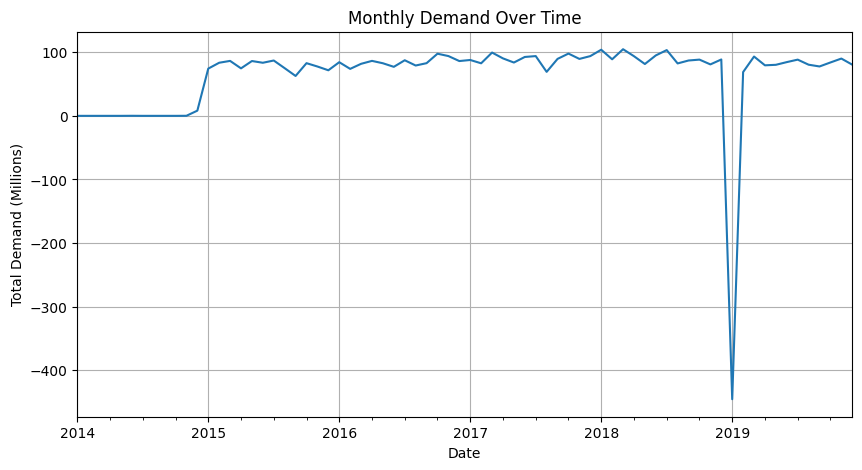

In [83]:
# Convert monthly demand into millions
monthly_demand_millions = monthly_demand / 1000000

# Plotting
monthly_demand_millions.plot(figsize=(10,5), grid=True)
plt.title("Monthly Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Total Demand (Millions)")
plt.show()

### Findings
- Demand is mostly positive and fairly stable from 2015 onward.This indicates that the business experiences recurring monthly demand at a large scale, which supports the use of time-series methods for forecasting. 
- There is a huge negative spike around 2019. The chart also confirms that cleaning the negative values was necessary to remove artificial drops and present a more realistic demand pattern.
- Monthly demand should usually not collapse that sharply unless there is a data issue or negative demand records.

## Data Cleaning and Outlier Handling

In [84]:
# Check the minimum values
df['Order_Demand'].describe()

count    1.035585e+06
mean     4.443019e+03
std      2.984357e+04
min     -1.631813e+05
25%      1.800000e+01
50%      3.000000e+02
75%      2.000000e+03
max      4.000000e+06
Name: Order_Demand, dtype: float64

In [85]:
df[df['Order_Demand'] < 0].head()

,Product_Code,Warehouse,Product_Category,Order_Demand
Date,,,,
2019-01-03,Product_1825,Surrey,Category_006,-69003.78787
2019-01-03,Product_0650,St john's,Category_022,-69167.05425
2019-01-03,Product_0982,St john's,Category_028,-69303.10956
2019-01-03,Product_0643,St john's,Category_028,-69275.89850
2019-01-03,Product_1844,St john's,Category_018,-69248.68744


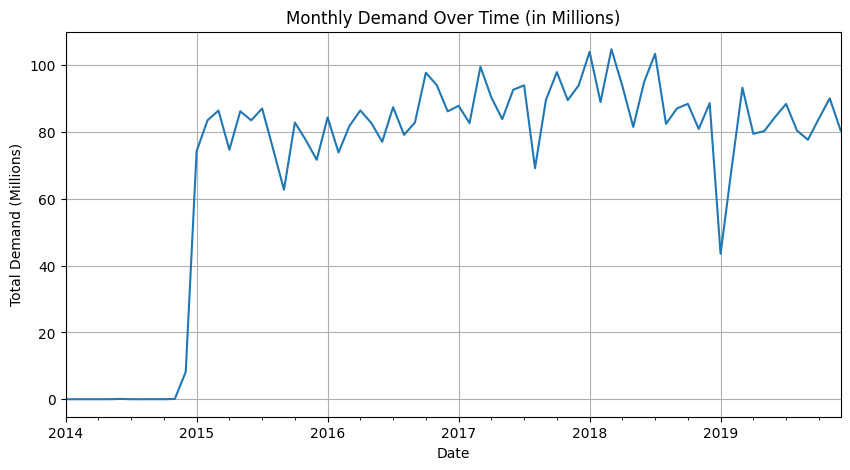

In [86]:
# Filtering only positive demand values
df = df[df['Order_Demand'] > 0]

# Resampling data on a monthly basis and summing demand
monthly_demand = df['Order_Demand'].resample('ME').sum()

# Converting into millions
monthly_demand_millions = monthly_demand / 1_000_000

# Plotting the monthly demand trend
monthly_demand_millions.plot(figsize=(10,5), grid=True)
plt.title("Monthly Demand Over Time (in Millions)")
plt.xlabel("Date")
plt.ylabel("Total Demand (Millions)")
plt.show()

After converting the Date column and removing invalid records, the dataset became suitable for time-based analysis. Negative demand values were also removed because they created unrealistic drops in the monthly trend and would distort forecasting results. This cleaning step improves the reliability of both the visual analysis and the forecasting mode

## Category-Level Demand Analysis

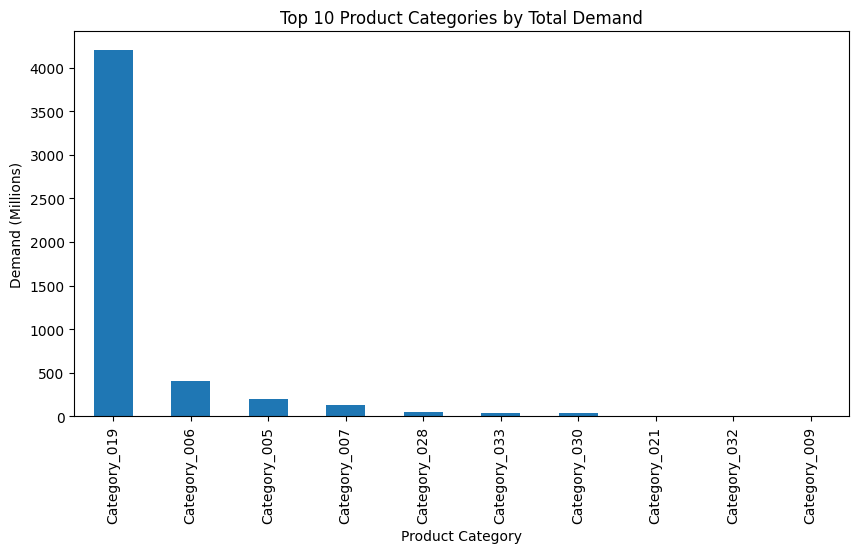

In [87]:
# Total demand by product category
category_demand = df.groupby('Product_Category')['Order_Demand'].sum().sort_values(ascending=False)

# Top 10 categories
top_10_categories = category_demand.head(10) / 1000000

# Plotting the bar chart
plt.figure(figsize=(10,5))
top_10_categories.plot(kind='bar')
plt.title("Top 10 Product Categories by Total Demand")
plt.xlabel("Product Category")
plt.ylabel("Demand (Millions)")
plt.show()

### Insights
Demand is highly concentrated in a small number of product categories. One category contributes far more demand than the others, which suggests that overall business performance is strongly influenced by a few major product groups. This is important from a planning perspective because forecasting attention should focus first on the highest-demand categories that drive the majority of volume.

## Warehouse Demand Distribution

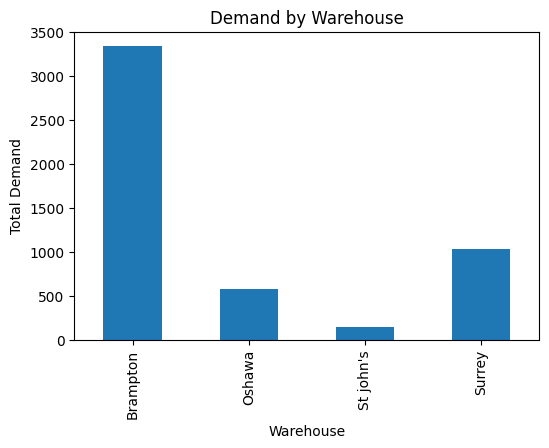

In [88]:
# WAREHOUSE ANALYSIS
warehouse_demand = df.groupby('Warehouse')['Order_Demand'].sum()

#Plotting bar chart 
warehouse_demand_millions=warehouse_demand/1000000
plt.figure(figsize=(6,4))
warehouse_demand_millions.plot(kind='bar')
plt.title("Demand by Warehouse")
plt.xlabel("Warehouse")
plt.ylabel("Total Demand")
plt.show()


### Insights
Demand is not evenly distributed across warehouses. Some warehouses handle much higher total demand than others, indicating regional or operational concentration. This means that inventory and replenishment decisions should not rely only on company wide totals, because warehouse level variation can affect stock availability, planning accuracy, and logistics performance.

## Top 5 Products

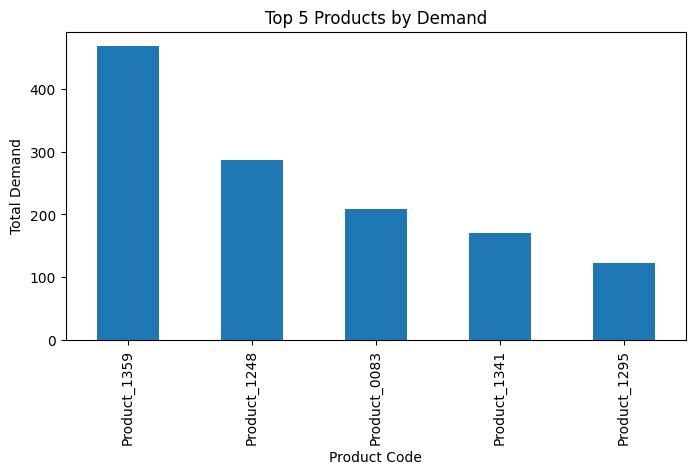

In [89]:
# Top Products Identification
top_products = df.groupby('Product_Code')['Order_Demand'].sum().sort_values(ascending=False).head(5)

# Plotting the bar chart
top_products_millions = top_products/1000000

plt.figure(figsize=(8,4))
top_products_millions.plot(kind='bar')
plt.title("Top 5 Products by Demand")
plt.xlabel("Product Code")
plt.ylabel("Total Demand")
plt.show()

## Insights
The demand distribution is also uneven at the product level. A small number of products generate much higher total demand than the rest, which supports the idea that product-level forecasting should focus on the most important SKUs first. High demand products are more valuable candidates for deeper time-series analysis because they contribute more directly to planning and inventory decisions

## Category Demand Over Time

<Figure size 1000x500 with 0 Axes>

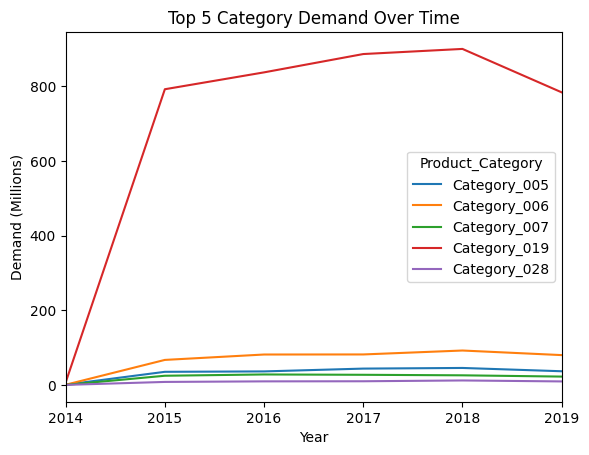

In [90]:
# Top 5 categories
top_categories = df.groupby('Product_Category')['Order_Demand'].sum().sort_values(ascending=False).head(5).index

# Filter only top 5 categories
category_time_top = df[df['Product_Category'].isin(top_categories)]

# Group by year and category
category_time_top = category_time_top.groupby([pd.Grouper(freq='YE'), 'Product_Category'])['Order_Demand'].sum().unstack()

# Convert into millions
category_time_top_millions = category_time_top/1000000

# Plot
plt.figure(figsize=(10,5))
category_time_top_millions.plot()
plt.title("Top 5 Category Demand Over Time")
plt.xlabel("Year")
plt.ylabel("Demand (Millions)")
plt.show()

### Insights
The yearly demand trend differs across major product categories. Some categories remain consistently strong, while others fluctuate more over time. This shows that demand patterns are not uniform across product groups, which means forecasting should not treat all categories the same. Stable categories may be easier to forecast, while more volatile categories may need closer monitoring.

## Top 5 Products Demand Over Time

In [91]:
# Find top 5 products 
top_5_products = df.groupby('Product_Code')['Order_Demand'].sum().sort_values(ascending=False).head(5)
print(top_5_products)

# Save their product codes
top_products_list = top_5_products.index

# Filter full dataset for those products
df_top_products = df[df['Product_Code'].isin(top_products_list)]

# Build monthly time series
top_products_time = df_top_products.groupby([pd.Grouper(freq='ME'), 'Product_Code'])['Order_Demand'].sum().unstack()

# Check output
print(top_products_time.head())

Product_Code
Product_1359    4.685470e+08
Product_1248    2.873250e+08
Product_0083    2.083725e+08
Product_1341    1.694754e+08
Product_1295    1.219263e+08
Name: Order_Demand, dtype: float64
Product_Code  Product_0083  Product_1248  Product_1295  Product_1341  \
Date                                                                   
2014-12-31             NaN           NaN           NaN     3366000.0   
2015-01-31       2789000.0     3772000.0     1360800.0     1269000.0   
2015-02-28       3668000.0     6369000.0     1380200.0     6813000.0   
2015-03-31       1980000.0     4533000.0     2190800.0     5306000.0   
2015-04-30       2531000.0     2557000.0     1817400.0     3038000.0   

Product_Code  Product_1359  
Date                        
2014-12-31             NaN  
2015-01-31       8911000.0  
2015-02-28       7682000.0  
2015-03-31       7775000.0  
2015-04-30       8960000.0  


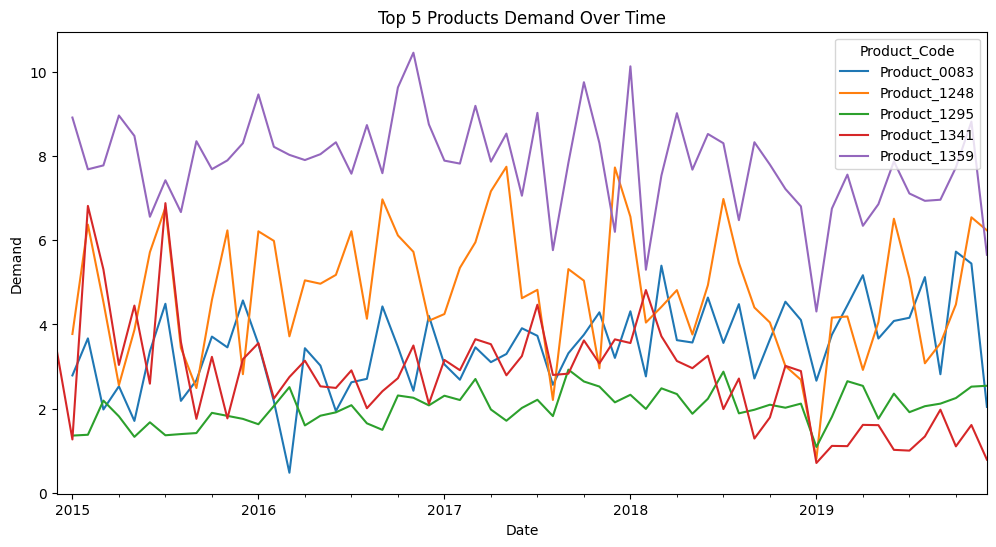

In [92]:
# Plotting the line chart
top_products_time_millions = top_products_time / 1000000
top_products_time_millions.plot(figsize=(12,6))
plt.title("Top 5 Products Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.show()

### Insights
Tracking the top 5 products from 2014 over the full period helps evaluate whether strong products remain consistently strong over time. The chart shows that some products have relatively stable demand, while others fluctuate more sharply. This comparison is useful because it helps justify the later selection of a product series for forecasting. Products with smoother and more stable demand are more appropriate for basic smoothing methods.

# Part 2: Time Series Forecasting

## Create the final product series

To improve forecasting accuracy, the demand series was segmented using both Product_Code and Warehouse instead of using aggregated product-level data. This allows the model to capture regional demand variations and provides more realistic insights for supply chain planning.

Based on the demand patterns observed in the chart Top 5 Products Over Time, Product_1341 was selected for forecasting. Although some products such as Product_1359 have higher demand, they exhibit significant fluctuations, making them less suitable for smoothing-based forecasting methods. Product_1341 shows a relatively stable demand pattern with moderate variability, making it more appropriate for applying methods such as Moving Average and Simple Exponential Smoothing.

In [93]:
# Group by Product_Code and Warehouse, then we will calcualte monthly demand
grouped_series = df.groupby(['Product_Code', 'Warehouse'])['Order_Demand'].resample('ME').sum()

In [94]:
# Checking which warehouses exist for Product_1341
df[df['Product_Code'] == 'Product_1341']['Warehouse'].value_counts()

Warehouse
Surrey    1885
Oshawa     768
Name: count, dtype: int64

In [95]:
# Select one valid combination
series_final = grouped_series.loc[('Product_1341', 'Surrey')]
series_final = series_final.asfreq('ME')

### Visualization of Selected Time Series

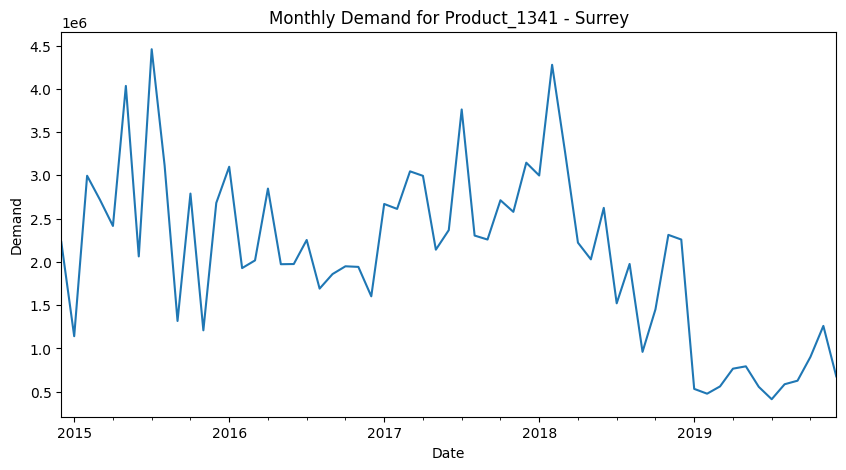

In [96]:
#Plotting
plt.figure(figsize=(10,5))
series_final.plot()
plt.title("Monthly Demand for Product_1341 - Surrey")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.show()

## Moving Average Method

The Moving Average method was applied using a rolling window of 3 periods. This method smooths short-term fluctuations and highlights the underlying trend in demand.

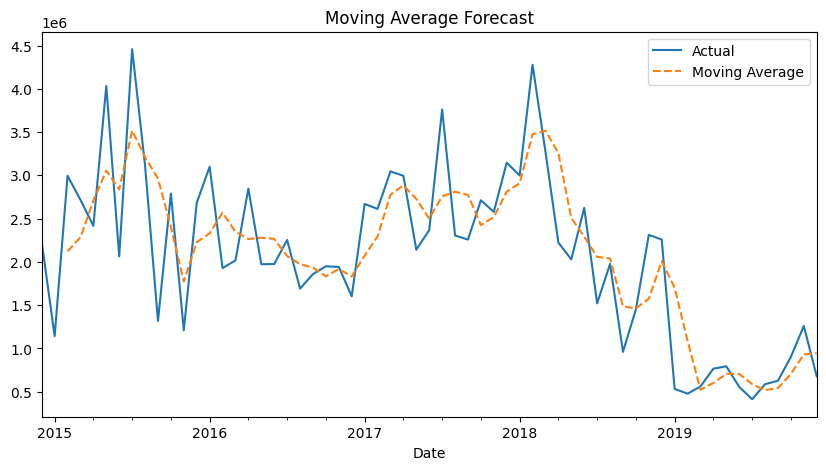

In [97]:
# Moving average (window = 3)
ma = series_final.rolling(3).mean()

# Plot
plt.figure(figsize=(10,5))
series_final.plot(label='Actual')
ma.plot(label='Moving Average', linestyle='--')
plt.legend()
plt.title("Moving Average Forecast")
plt.show()

## Insight
The Moving Average produces a smooth curve that reduces noise in the data. However, it tends to lag behind actual demand changes, especially when there are sudden increases or decreases.

# Simple Exponential Smoothing (SES)

Simple Exponential Smoothing (SES) was applied to the time series with a smoothing level of 0.2. This method assigns more weight to recent observations, allowing the model to respond more quickly to changes in demand.

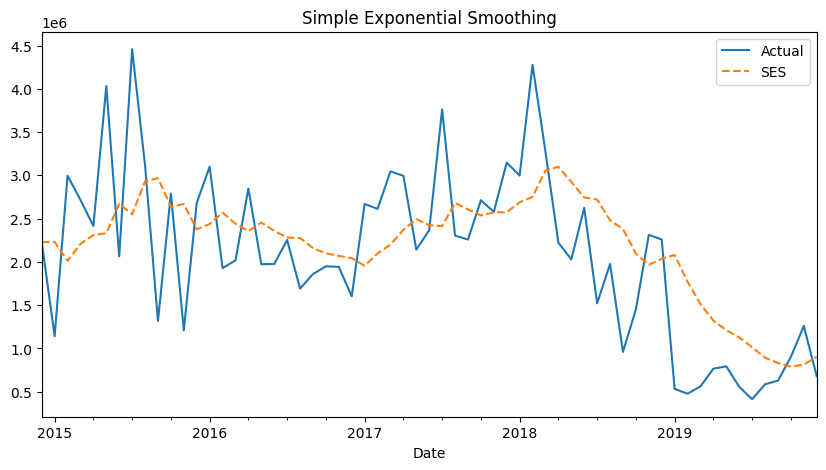

In [98]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Fit model on full data
ses_model = ExponentialSmoothing(series_final).fit(smoothing_level=0.2)

# Fitted values
ses_fitted = ses_model.fittedvalues

# Plot
plt.figure(figsize=(10,5))
series_final.plot(label='Actual')
ses_fitted.plot(label='SES', linestyle='--')
plt.legend()
plt.title("Simple Exponential Smoothing")
plt.show()

## Insight

Compared to Moving Average, SES reacts more effectively to recent demand variations and provides a closer fit to the actual data. However, it may introduce slight variability in the fitted values.

# ARIMA Model
The ARIMA (AutoRegressive Integrated Moving Average) model was applied with parameters (1,1,1). This model captures both trend and temporal dependencies in the data.

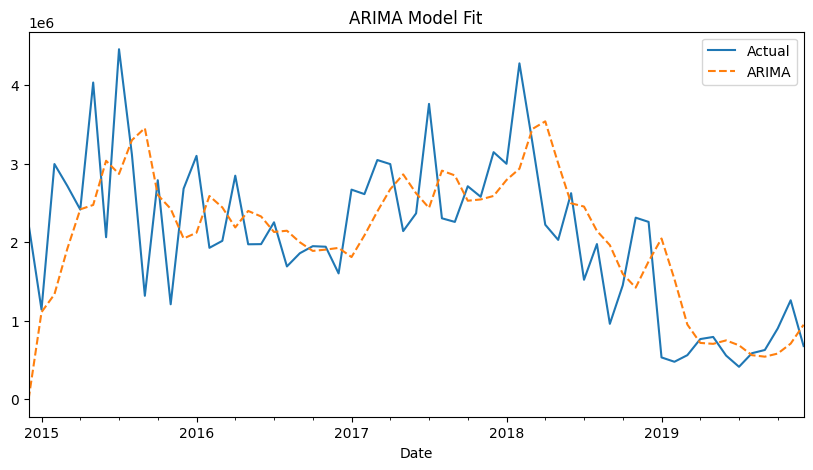

In [99]:
from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA on full data
arima_model = ARIMA(series_final, order=(1,1,1))
arima_fit = arima_model.fit()

# Fitted values
arima_fitted = arima_fit.predict(start=0, end=len(series_final)-1)

# Plotting 
plt.figure(figsize=(10,5))
series_final.plot(label='Actual')
arima_fitted.plot(label='ARIMA', linestyle='--')
plt.legend()
plt.title("ARIMA Model Fit")
plt.show()

## Insight
The ARIMA model follows the actual demand pattern more closely than the other methods. It captures fluctuations effectively, although it may introduce slightly more complexity and variability.

# Visual Comparison Insight


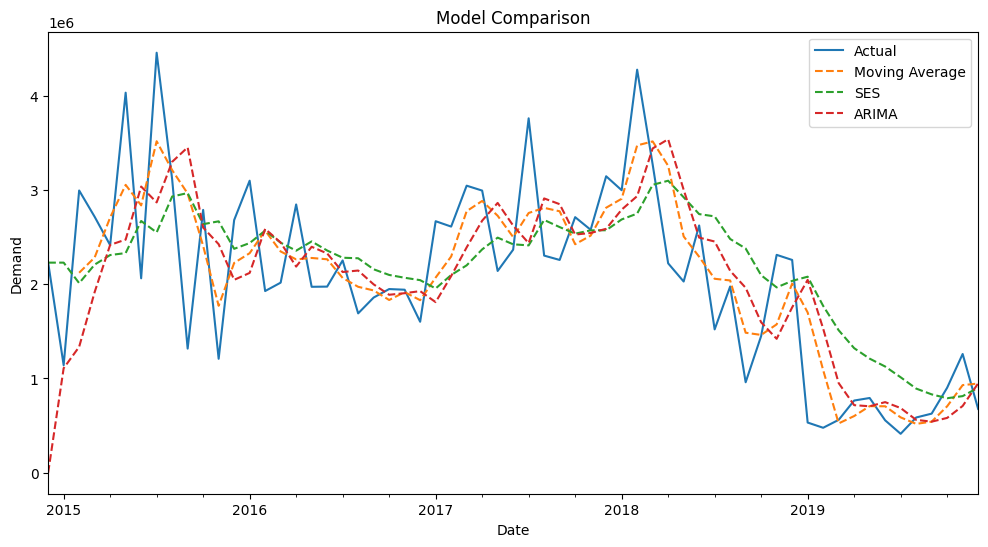

In [100]:

plt.figure(figsize=(12,6))
series_final.plot(label='Actual')
ma.plot(label='Moving Average', linestyle='--')
ses_fitted.plot(label='SES', linestyle='--')
arima_fitted.plot(label='ARIMA', linestyle='--')
plt.legend()
plt.title("Model Comparison")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.show()

# Insights
A combined plot of all models shows that the Moving Average provides a smooth representation of the demand trend, while SES and ARIMA attempt to follow more detailed fluctuations. Although ARIMA tracks changes more closely, it introduces more variability, whereas Moving Average offers a more stable and consistent fit.

## Model Comparison
The forecasting models were evaluated using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE). These metrics are calculated by comparing the fitted values of each model with the actual demand values.

In [101]:
# Model Comparison using MAE and RMSE

# Moving Average 
mae_ma = mean_absolute_error(series_final[2:], ma[2:])
rmse_ma = np.sqrt(mean_squared_error(series_final[2:], ma[2:]))

# Simple Exponential Smoothing
mae_ses = mean_absolute_error(series_final, ses_fitted)
rmse_ses = np.sqrt(mean_squared_error(series_final, ses_fitted))

# ARIMA
mae_arima = mean_absolute_error(series_final, arima_fitted)
rmse_arima = np.sqrt(mean_squared_error(series_final, arima_fitted))


In [102]:
# Creating the  comparison table
results = pd.DataFrame({
    'Method': ['Moving Average', 'Simple Exponential Smoothing', 'ARIMA'],
    'MAE': [mae_ma, mae_ses, mae_arima],
    'RMSE': [rmse_ma, rmse_ses, rmse_arima]
})

print(results)

                         Method            MAE           RMSE
0                Moving Average  414345.861789  531604.419553
1  Simple Exponential Smoothing  603541.582149  768039.232106
2                         ARIMA  607709.737266  810763.284739


# Insights
The results show that the Moving Average model has the lowest MAE and RMSE values, indicating the best overall performance among the three models. The Simple Exponential Smoothing and ARIMA models show higher error values, suggesting that they are less accurate for this particular time series.

# Final Model Selection

Based on both error metrics and visual comparison, the Moving Average model is selected as the best-performing model. It provides the lowest error values and offers a stable and interpretable representation of demand.

# Business Insight

Accurate demand forecasting helps improve inventory planning, reduce stockouts, and optimize supply chain operations. By using a segmented approach based on Product_Code and Warehouse, the model captures regional demand variations more effectively.

The selection of a simple and stable model such as Moving Average is beneficial for operational decision-making, as it is easy to implement and update with new data.